## Исследование влияния параметров в алгоритме минимизации на качество обучения 

In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


Импорты библиотек

In [1]:
from input_generator import generate
from w_solution import get_W
from swarp import Swarp
from utils import get_random
from time import time
from matplotlib import pyplot as plt 

Создаем новые исходные данные

In [9]:
generate()


10 типов местности успешно сохранены по пути c:\055\data\landscapes.json
Местность 10x10 успешно создана
Параметры успешно сохранены в c:\055\data\params.json


### Тест 1

Результат расчета W без оптимизации параметров на случайно сгенерированных альфа и бета

In [2]:
from json import loads
from settings import PARAMS_PATH

with open(PARAMS_PATH) as f:
    params = loads(f.read())

alpha = params['a']
beta = params['b']

get_W(alpha, beta)

48.463004265063034

### Тест 2

Результат расчета W c оптимизацией на следующих параметрах:
* Количество частиц = 30
* Минимальное количество выбираемых соседей 15
* Максимальное количество выбираемых соседей 25
* Количество иттераций = 200
* Весовой коэффициент инерции = 0.01
* Параметр альфа = 0.6084719263928644
* Параметр бета = 0.8775191704540811

In [3]:
np = 30
ni_min = 15
ni_max=25
k=200
weight=0.01
a=0.6084719263928644
b=0.8775191704540811

In [4]:
swarp = Swarp(np, ni_min, ni_max, k, weight, a, b)
swarp.optimize()

25.351711310107326

### Тест 3

Анализ зависимости скорости обучения и стандартного отклонения от значения np (количество частиц)

Все остальные параметры берутся из теста 2

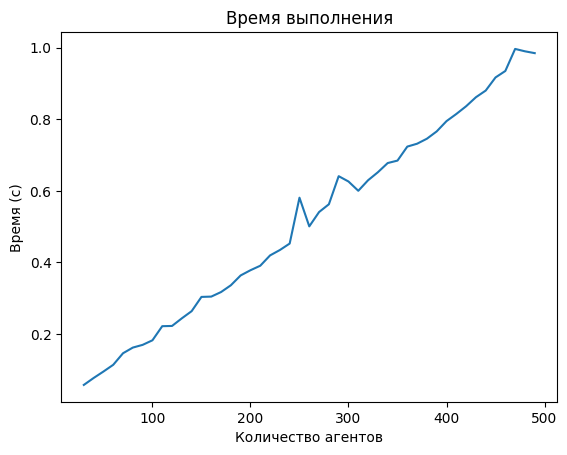

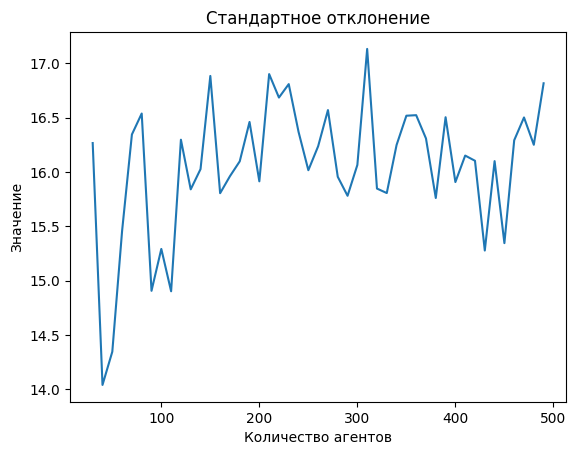

In [11]:
# перебираемые значения количества частиц ([30, 40, ..., 490])
nps = range(30, 500, 10)

# время выполнения
times = []

# стандартные отклонения
deviations = []

# лучший w
w_s = []

# alphas
a_s = {}

# betas
b_s = {}

# улучшаемые a и b
temp_a = a
temp_b = b

# для каждого возможного количества 
for _np in nps:
    start_time = time()
    # print(temp_a, temp_b)
    _swarp = Swarp(_np, ni_min, ni_max, k, weight, temp_a, temp_b)
    w_s.append(_swarp.optimize())
    end_time = time()
    temp_a = _swarp.a
    temp_b = _swarp.b
    a_s[temp_a] = w_s[-1]
    b_s[temp_b] = w_s[-1]
    deviation = _swarp.get_standard_deviation()
    deviations.append(deviation)
    delta_time = end_time - start_time
    # print(f"При np = {_np} время выполнения = {delta_time}")
    times.append(delta_time)

# print(times)
 
# plt.plot(nps, ws) 
# plt.title("Значение w")
# plt.xlabel("Количество агентов")
# plt.ylabel("Значение")

# plt.show()

# plt.subplot(1, 3, 1)

# sorted_a_s = dict(sorted(a_s.items(), key=lambda item: item[0]))
# sorted_b_s = dict(sorted(b_s.items(), key=lambda item: item[0]))

# plt.plot(sorted_a_s.keys(), sorted_a_s.values()) 
# plt.title("Зависимость W от значения alpha")
# plt.xlabel("Значение alpha")
# plt.ylabel("Значение W")

# plt.show()

# plt.plot(sorted_b_s.keys(), sorted_b_s.values()) 
# plt.title("Зависимость W от значения beta")
# plt.xlabel("Значение beta")
# plt.ylabel("Значение W")

plt.show()

plt.plot(nps, times) 
plt.title("Время выполнения")
plt.xlabel("Количество агентов")
plt.ylabel("Время (с)")

plt.show()

# plt.subplot(1, 3, 3)

plt.plot(nps, deviations) 
plt.title("Стандартное отклонение")
plt.xlabel("Количество агентов")
plt.ylabel("Значение")

plt.show()

### Тест 4

Анализ зависимости скорости обучения от значения ni_min (минимальное количество выбираемых соседей)

Все остальные параметры берутся из теста 2

ni_max берется по умолчанию как np

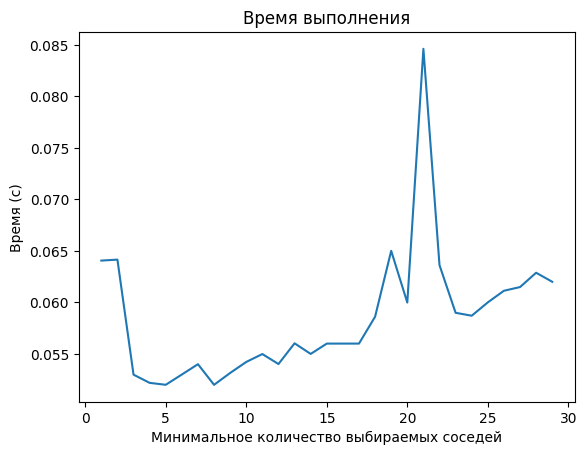

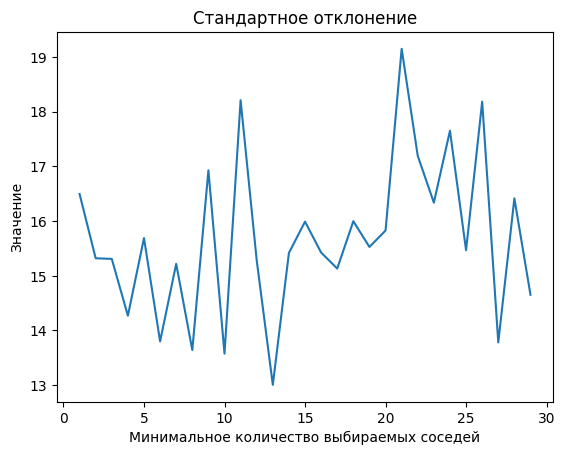

In [12]:
# перебираемые значения ([1, 2, ..., np])
ni_mins = list(range(1, np))

# максимальное количество выбираемых соседей для теста
_ni_max = np

# время выполнения
times = []

# стандартные отклонения
deviations = []

# лучший w
w_s = []

# alphas
a_s = {}

# betas
b_s = {}

# улучшаемые a и b
temp_a = a
temp_b = b

# для каждого возможного количества 
for _ni_min in ni_mins:
    start_time = time()
    _swarp = Swarp(np, _ni_min, _ni_max, k, weight, a, b)
    w_s.append(_swarp.optimize())
    end_time = time()
    temp_a = _swarp.a
    temp_b = _swarp.b
    a_s[temp_a] = w_s[-1]
    b_s[temp_b] = w_s[-1]
    deviation = _swarp.get_standard_deviation()
    deviations.append(deviation)
    delta_time = end_time - start_time
    # print(f"При np = {_np} время выполнения = {delta_time}")
    times.append(delta_time)

sorted_a_s = dict(sorted(a_s.items(), key=lambda item: item[0]))
sorted_b_s = dict(sorted(b_s.items(), key=lambda item: item[0]))

# plt.plot(sorted_a_s.keys(), sorted_a_s.values()) 
# plt.title("Зависимость W от значения alpha")
# plt.xlabel("Значение alpha")
# plt.ylabel("Значение W")

# plt.show()

# plt.plot(sorted_b_s.keys(), sorted_b_s.values()) 
# plt.title("Зависимость W от значения beta")
# plt.xlabel("Значение beta")
# plt.ylabel("Значение W")

# plt.show()

# print(times)
 
# plt.plot(ni_mins, w_s) 
# plt.title("Значение w")
# plt.xlabel("Минимальное количество выбираемых соседей")
# plt.ylabel("Значение")

# plt.show()

# plt.subplot(1, 3, 1)

plt.plot(ni_mins, times) 
plt.title("Время выполнения")
plt.xlabel("Минимальное количество выбираемых соседей")
plt.ylabel("Время (с)")

plt.show()

# plt.subplot(1, 3, 3)

plt.plot(ni_mins, deviations) 
plt.title("Стандартное отклонение")
plt.xlabel("Минимальное количество выбираемых соседей")
plt.ylabel("Значение")

plt.show()

### Тест 5

Анализ зависимости скорости обучения от значения ni_max (максимальное количество выбираемых соседей)

Все остальные параметры берутся из теста 2

ni_min берется по умолчанию как 1

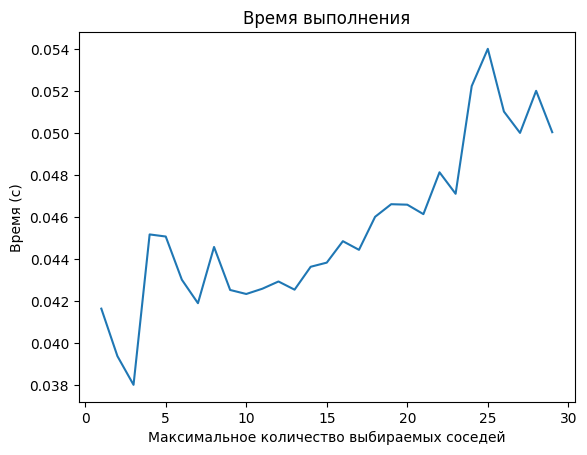

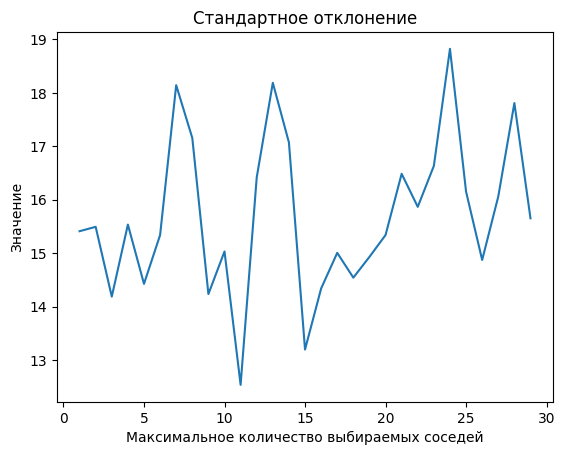

In [13]:
# минимальное количество выбираемых соседей для теста
_ni_min = 1

# перебираемые значения ([1, 2, ..., np])
ni_maxes = list(range(_ni_min, np))

# время выполнения
times = []

# стандартные отклонения
deviations = []

# лучший w
w_s = []

# для каждого возможного количества 
for _ni_max in ni_maxes:
    start_time = time()
    _swarp = Swarp(np, _ni_min, _ni_max, k, weight, a, b)
    w_s.append(_swarp.optimize())
    end_time = time()
    deviation = _swarp.get_standard_deviation()
    deviations.append(deviation)
    delta_time = end_time - start_time
    # print(f"При np = {_np} время выполнения = {delta_time}")
    times.append(delta_time)

# print(times)
 
# plt.plot(ni_maxes, w_s) 
# plt.title("Значение w")
# plt.xlabel("Максимальное количество выбираемых соседей")
# plt.ylabel("Значение")

# plt.show()

# plt.subplot(1, 3, 1)

plt.plot(ni_maxes, times) 
plt.title("Время выполнения")
plt.xlabel("Максимальное количество выбираемых соседей")
plt.ylabel("Время (с)")

plt.show()

# plt.subplot(1, 3, 3)

plt.plot(ni_maxes, deviations) 
plt.title("Стандартное отклонение")
plt.xlabel("Максимальное количество выбираемых соседей")
plt.ylabel("Значение")

plt.show()

### Тест 6

Анализ зависимости скорости обучения от значения k (количество иттераций)

Все остальные параметры берутся из теста 2

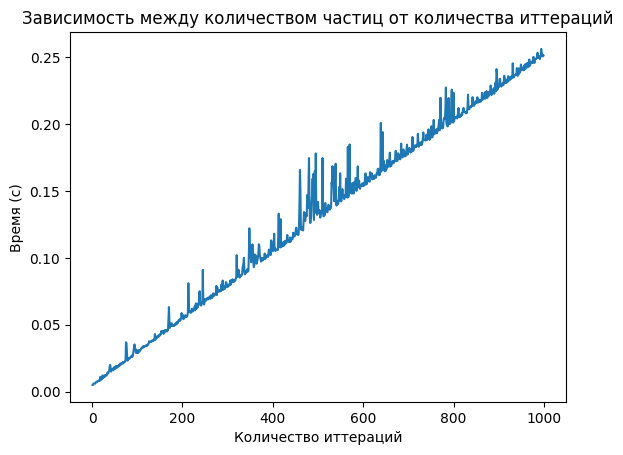

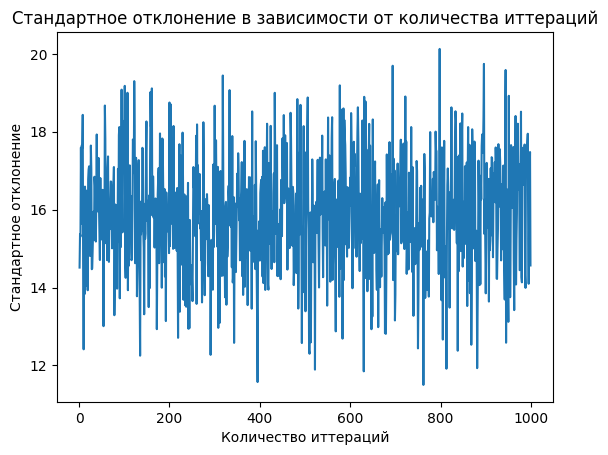

In [14]:
# перебираемые значения ([1, 2, ..., 1000])
ks = list(range(1, 1000))

# время выполнения
times = []

# стандартные отклонения
deviations = []

# лучший w
w_s = []

# для каждого возможного количества 
for _k in ks:
    start_time = time()
    _swarp = Swarp(np, ni_min, ni_max, _k, weight, a, b)
    w_s.append(_swarp.optimize())
    end_time = time()
    deviation = _swarp.get_standard_deviation()
    deviations.append(deviation)
    delta_time = end_time - start_time
    # print(f"При np = {_np} время выполнения = {delta_time}")
    times.append(delta_time)

# print(times)
 
# plt.plot(ks, w_s) 
# plt.title("Значение w")
# plt.xlabel("Максимальное количество выбираемых соседей")
# plt.ylabel("Значение")

# plt.show()

# plt.subplot(1, 3, 1)

plt.plot(ks, times) 
plt.title("Зависимость между количеством частиц от количества иттераций")
plt.xlabel("Количество иттераций")
plt.ylabel("Время (с)")

plt.show()

# plt.subplot(1, 3, 3)

plt.plot(ks, deviations) 
plt.title("Стандартное отклонение в зависимости от количества иттераций")
plt.xlabel("Количество иттераций")
plt.ylabel("Стандартное отклонение")

plt.show()

### Тест 7

Анализ зависимости скорости обучения от значения weight (весового коэффициента инерции)

Все остальные параметры берутся из теста 2

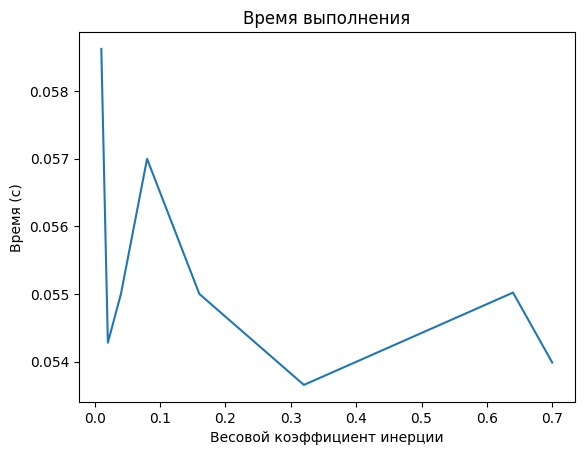

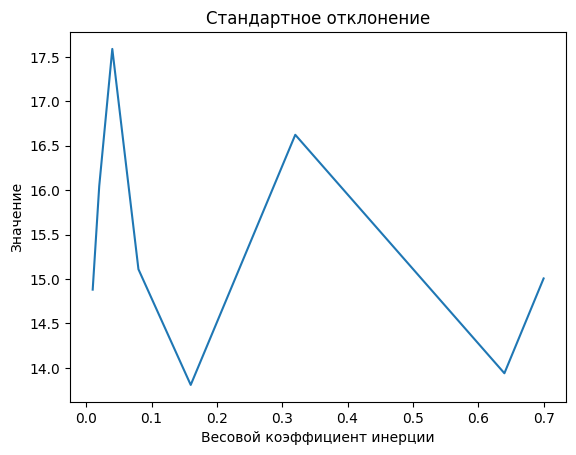

In [15]:
# перебираемые значения ([0.01, 2, ..., 1000])
weights = [0.01, 0.02, 0.04, 0.08, 0.16, 0.32, 0.64, 0.7]

# время выполнения
times = []

# стандартные отклонения
deviations = []

# лучший w
w_s = []

# для каждого возможного количества 
for _weight in weights:
    start_time = time()
    _swarp = Swarp(np, ni_min, ni_max, k, _weight, a, b)
    w_s.append(_swarp.optimize())
    end_time = time()
    deviation = _swarp.get_standard_deviation()
    deviations.append(deviation)
    delta_time = end_time - start_time
    # print(f"При np = {_np} время выполнения = {delta_time}")
    times.append(delta_time)

# print(times)
 
# plt.plot(weights, w_s) 
# plt.title("Значение w")
# plt.xlabel("Весовой коэффициент инерции")
# plt.ylabel("Значение")

# plt.show()

# plt.subplot(1, 3, 1)

plt.plot(weights, times) 
plt.title("Время выполнения")
plt.xlabel("Весовой коэффициент инерции")
plt.ylabel("Время (с)")

plt.show()

# plt.subplot(1, 3, 3)

plt.plot(weights, deviations) 
plt.title("Стандартное отклонение")
plt.xlabel("Весовой коэффициент инерции")
plt.ylabel("Значение")

plt.show()

### Тест 8

Анализ зависимости скорости обучения от значения параметра альфа

Все остальные параметры берутся из теста 2

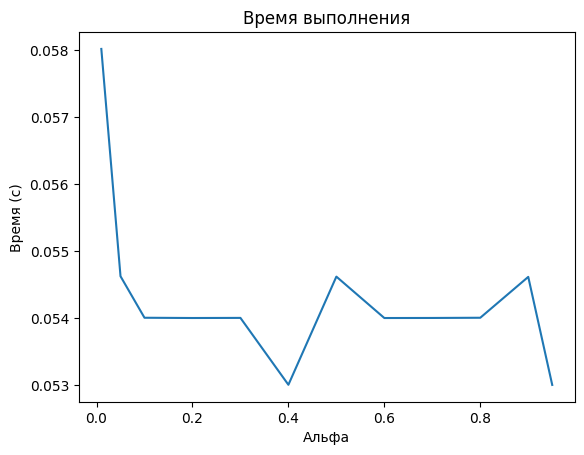

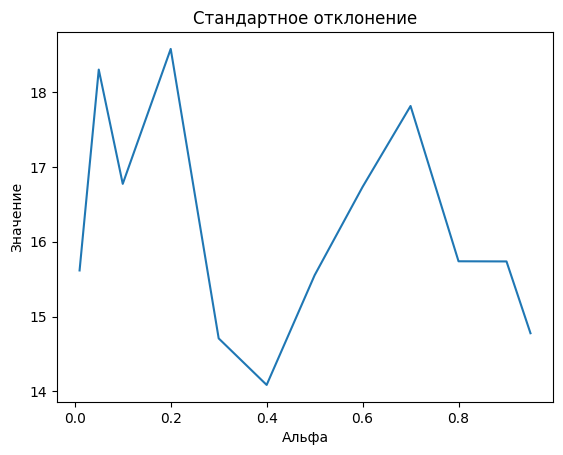

In [16]:
# перебираемые значения ([0.01, 2, ..., 1000])
alphas = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

# время выполнения
times = []

# стандартные отклонения
deviations = []

# лучший w
w_s = []

# для каждого возможного количества 
for _a in alphas:
    start_time = time()
    _swarp = Swarp(np, ni_min, ni_max, k, weight, _a, b)
    w_s.append(_swarp.optimize())
    end_time = time()
    deviation = _swarp.get_standard_deviation()
    deviations.append(deviation)
    delta_time = end_time - start_time
    # print(f"При np = {_np} время выполнения = {delta_time}")
    times.append(delta_time)

# print(times)
 
# plt.plot(alphas, w_s) 
# plt.title("Значение w")
# plt.xlabel("Альфа")
# plt.ylabel("Значение")

# plt.show()

# plt.subplot(1, 3, 1)

plt.plot(alphas, times) 
plt.title("Время выполнения")
plt.xlabel("Альфа")
plt.ylabel("Время (с)")

plt.show()

# plt.subplot(1, 3, 3)

plt.plot(alphas, deviations) 
plt.title("Стандартное отклонение")
plt.xlabel("Альфа")
plt.ylabel("Значение")

plt.show()

### Тест 9

Анализ зависимости скорости обучения от значения параметра бета

Все остальные параметры берутся из теста 2

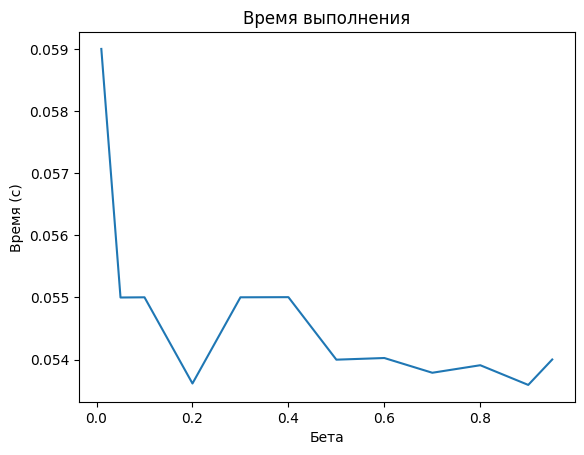

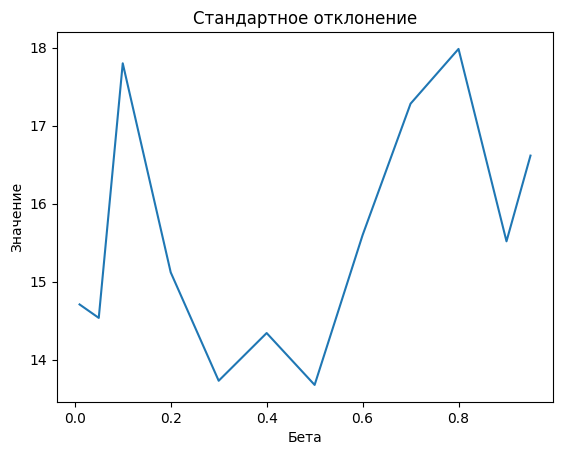

In [17]:
# перебираемые значения ([0.01, 2, ..., 1000])
betas = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

# время выполнения
times = []

# стандартные отклонения
deviations = []

# лучший w
w_s = []

# для каждого возможного количества 
for _b in betas:
    start_time = time()
    _swarp = Swarp(np, ni_min, ni_max, k, weight, a, _b)
    w_s.append(_swarp.optimize())
    end_time = time()
    deviation = _swarp.get_standard_deviation()
    deviations.append(deviation)
    delta_time = end_time - start_time
    # print(f"При np = {_np} время выполнения = {delta_time}")
    times.append(delta_time)

# print(times)
 
# plt.plot(betas, w_s) 
# plt.title("Значение w")
# plt.xlabel("Бета")
# plt.ylabel("Значение")

# plt.show()

# plt.subplot(1, 3, 1)

plt.plot(betas, times) 
plt.title("Время выполнения")
plt.xlabel("Бета")
plt.ylabel("Время (с)")

plt.show()

# plt.subplot(1, 3, 3)

plt.plot(betas, deviations) 
plt.title("Стандартное отклонение")
plt.xlabel("Бета")
plt.ylabel("Значение")

plt.show()

Исследование изменения значения W в зависимости от значения alpha и beta

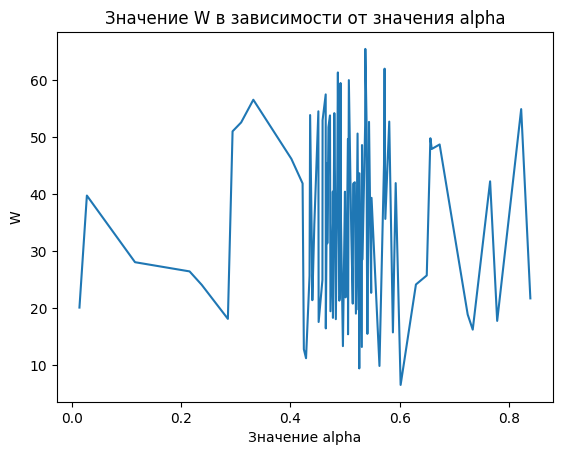

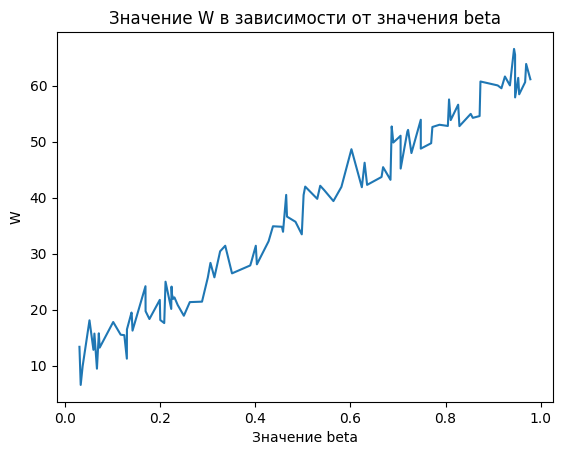

In [22]:
# alphas
a_s = {}

# betas
b_s = {}

# улучшаемые a и b
temp_a = a
temp_b = b

# для каждого возможного количества 
for step in range(100):
    _swarp = Swarp(_np, _ni_min, _ni_max, _k, _weight, temp_a, temp_b)
    w = _swarp.optimize()
    temp_a = _swarp.a if _swarp.a >= 0 and _swarp.a <= 1 else temp_a
    temp_b = _swarp.b if _swarp.b >= 0 and _swarp.b <= 1 else temp_b
    a_s[temp_a] = w
    b_s[temp_b] = w

sorted_a_s = dict(sorted(a_s.items(), key=lambda item: item[0]))
sorted_b_s = dict(sorted(b_s.items(), key=lambda item: item[0]))

plt.plot(sorted_a_s.keys(), sorted_a_s.values()) 
plt.title("Значение W в зависимости от значения alpha")
plt.xlabel("Значение alpha")
plt.ylabel("W")

plt.show()

plt.plot(sorted_b_s.keys(), sorted_b_s.values()) 
plt.title("Значение W в зависимости от значения beta")
plt.xlabel("Значение beta")
plt.ylabel("W")

plt.show()